In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

# Layer 3 Library: Vector Autoregression
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error

# Layer 2 Library: PC Algorithm
# (Requires: pip install causal-learn)
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.GraphUtils import GraphUtils

/Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/08 - side quests/network-dynamics-failure-propagation/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# STAGE 0: COMPLEX DATA GENERATION
np.random.seed(42)
continents = ['North America', 'Europe', 'Asia', 'South America', 'Africa']
samples_per_continent = 300 

all_data = []

for region in continents:
    # 1. Define Regional Biases
    bias_sleep = np.random.randint(-5, 5)
    bias_vo2 = np.random.randint(-5, 5)
    bias_glucose = np.random.randint(-5, 10)
    
    # Initialize Matrix (N days x 7 variables)
    data = np.zeros((samples_per_continent, 7))
    
    # Initial Baseline Values
    # Sleep(75), Mood(7), Act(5000), RHR(60), HRV(50), VO2(45), Gluc(90)
    data[0, :] = [75, 7, 5000, 60, 50, 45, 90]
    
    for t in range(1, samples_per_continent):
        # Fetch Yesterday's values
        p_sleep, p_mood, p_act, p_rhr, p_hrv, p_vo2, p_gluc = data[t-1, :]
        
        # --- THE BIOLOGICAL ENGINE ---
        
        # 1. SLEEP: Autoregressive + random variation
        new_sleep = 0.3 * p_sleep + 50 + np.random.normal(0, 8) + bias_sleep
        new_sleep = np.clip(new_sleep, 0, 100)
        
        # 2. HRV: Driven by SLEEP and MOOD
        new_hrv = 0.4 * p_hrv + 0.3 * (p_sleep - 50) + 2 * p_mood + np.random.normal(0, 5)
        
        # 3. RESTING HR (RHR): Inverse to HRV and Sleep
        new_rhr = 0.6 * p_rhr - 0.1 * (new_hrv - 50) - 0.1 * (p_sleep - 70) + np.random.normal(0, 2)
        
        # 4. MOOD: Driven by SLEEP and HRV
        new_mood = 0.4 * p_mood + 0.05 * p_sleep + 0.02 * p_hrv + np.random.normal(0, 1)
        new_mood = np.clip(new_mood, 1, 10)
        
        # 5. ACTIVITY: Driven by MOOD and VO2 Max
        new_act = 0.5 * p_act + 500 * p_mood + 50 * p_vo2 + np.random.normal(0, 1000)
        
        # 6. VO2 MAX: Slow moving, driven by ACTIVITY history
        new_vo2 = 0.95 * p_vo2 + 0.0001 * p_act + np.random.normal(0, 0.2) + (bias_vo2 * 0.01)
        
        # 7. FASTING GLUCOSE: Inverse to ACTIVITY and SLEEP
        new_gluc = 0.7 * p_gluc - 0.001 * p_act - 0.1 * (p_sleep - 70) + 30 + np.random.normal(0, 3) + bias_glucose

        data[t, :] = [new_sleep, new_mood, new_act, new_rhr, new_hrv, new_vo2, new_gluc]

    df_region = pd.DataFrame(data, columns=['Sleep', 'Mood', 'Activity', 'RHR', 'HRV', 'VO2_Max', 'Glucose'])
    df_region['Continent'] = region
    all_data.append(df_region)

df_master = pd.concat(all_data).reset_index(drop=True)
print("Stage 0 Complete: Data Generated for 7 Parameters.")
print(df_master.describe().round(1).loc[['mean', 'std', 'min', 'max']])

Stage 0 Complete: Data Generated for 7 Parameters.
      Sleep  Mood  Activity   RHR   HRV  VO2_Max  Glucose
mean   70.2   6.9    8850.6   4.5  33.5     19.5     76.9
std     9.6   1.4    1754.9   5.6   8.4      5.4     20.2
min    41.9   1.7    2717.9  -7.6   3.0     11.2     35.7
max    99.9  10.0   14377.0  60.0  56.6     45.0    111.2


In [3]:
# STAGE 1: TRAIN/TEST SPLIT
test_continent = 'Asia'
train_cols = ['Sleep', 'Mood', 'Activity', 'RHR', 'HRV', 'VO2_Max', 'Glucose']

# Training Data: Everyone EXCEPT Asia
df_train = df_master[df_master['Continent'] != test_continent][train_cols]

# Test Data: ONLY Asia
df_test = df_master[df_master['Continent'] == test_continent][train_cols]

print(f"Stage 1 Complete: Data Split.")
print(f"   Training Samples: {len(df_train)}")
print(f"   Testing Samples: {len(df_test)} (Continent: {test_continent})")


Stage 1 Complete: Data Split.
   Training Samples: 1200
   Testing Samples: 300 (Continent: Asia)


Stage 2: Running PC Algorithm...


Depth=4, working on node 6: 100%|██████████| 7/7 [00:00<00:00, 2890.63it/s]


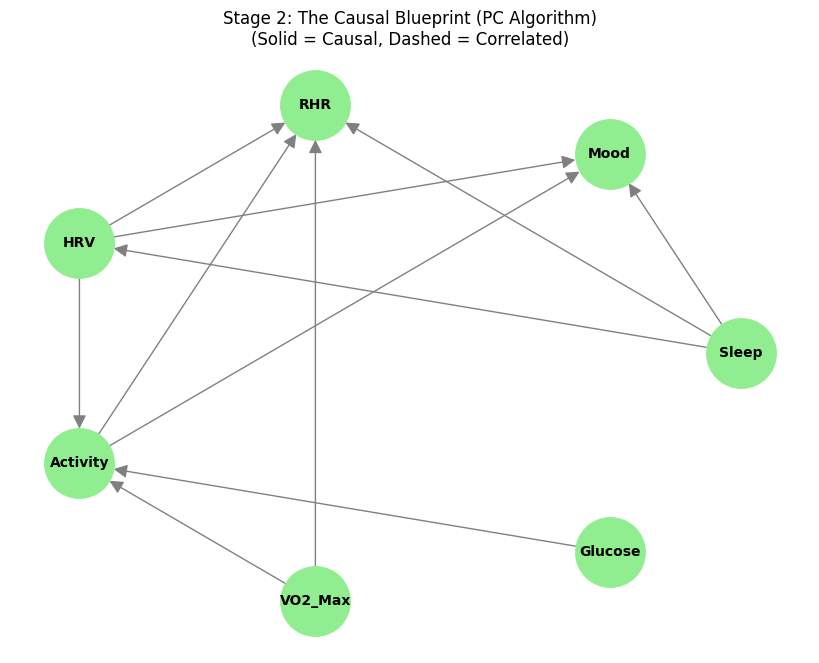

Stage 2 Complete: Causal Topology Discovered.


In [4]:
# STAGE 2: CAUSAL DISCOVERY (PC Algorithm)

# This stage draws the "Skeleton" of the graph based on conditional independence.
# It tells us WHAT connects to WHAT, before we ask "how much" or "when".

from causallearn.search.ConstraintBased.PC import pc

print("Stage 2: Running PC Algorithm...")

# 1. Prepare Data
# PC requires a simple NumPy matrix of the training data
data_matrix = df_train.to_numpy()
labels = df_train.columns

# 2. Run the Algorithm
# alpha=0.05 is the standard statistical threshold (p-value)
# indep_test='fisherz' is the standard test for continuous data (like HR, Glucose)
cg = pc(data_matrix, alpha=0.05, indep_test='fisherz', verbose=False)

# 3. Visualization
# We convert the PC output into a NetworkX graph to draw it
G_pc = nx.DiGraph()
adj_matrix = cg.G.graph

for i in range(len(labels)):
    for j in range(len(labels)):
        # Interpretation of PC Output Matrix:
        # [j, i] == 1 AND [i, j] == -1  =>  Directed Edge (i -> j)
        if adj_matrix[j, i] == 1 and adj_matrix[i, j] == -1:
            G_pc.add_edge(labels[i], labels[j])
            
        # [j, i] == -1 AND [i, j] == -1 =>  Undirected Edge (Correlation found, direction unclear)
        elif adj_matrix[i, j] == -1 and adj_matrix[j, i] == -1:
            if i < j: # Avoid duplicates
                G_pc.add_edge(labels[i], labels[j], style='dashed')

# 4. Plotting
plt.figure(figsize=(8, 6))

# Use circular layout because we have 7 nodes (prevents a messy hairball)
pos = nx.circular_layout(G_pc) 

nx.draw(G_pc, pos, with_labels=True, node_color='lightgreen', 
        node_size=2500, font_weight='bold', font_size=10, 
        arrowsize=20, edge_color='gray')

plt.title("Stage 2: The Causal Blueprint (PC Algorithm)\n(Solid = Causal, Dashed = Correlated)")
plt.show()

print("Stage 2 Complete: Causal Topology Discovered.")

In [5]:
# STEP 3: LAYER 3 - TEMPORAL DYNAMICS (VAR Model)
# Goal: Quantify the *strength* and *timing* of the edges found in Layer 2.
model = VAR(df_train)

# We use Lag 2 here (looking back 2 days)
results = model.fit(maxlags=2) 

print("\nStage 3 Complete: Model Trained.")
print("   Checking Logic: Does 'Activity' lower 'Glucose'?")

# Row = The Cause (Activity yesterday -> L1.Activity)
# Column = The Effect (Glucose today)
coef = results.params.loc['L1.Activity', 'Glucose']

print(f"   Coefficient (Activity -> Glucose): {coef:.5f} ({'Correct (Negative)' if coef < 0 else 'Incorrect'})")


Stage 3 Complete: Model Trained.
   Checking Logic: Does 'Activity' lower 'Glucose'?
   Coefficient (Activity -> Glucose): -0.00079 (Correct (Negative))


/Users/isabellamueller-vogt/Library/Mobile Documents/com~apple~CloudDocs/08 - side quests/network-dynamics-failure-propagation/venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


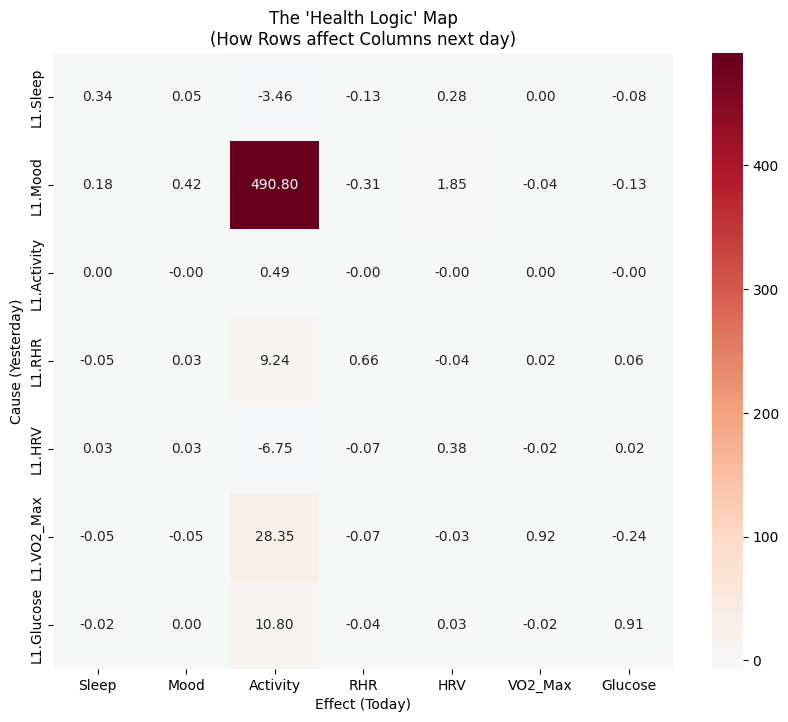

Stage 4 Complete: Heatmap generated.


In [6]:
# STAGE 4: VISUALIZE THE NETWORK

# Extract Lag-1 Causal Matrix (How Yesterday affects Today)
matrix_l1 = results.params.iloc[1:8, :] # Skip intercept row

plt.figure(figsize=(10, 8))
sns.heatmap(matrix_l1, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title("The 'Health Logic' Map\n(How Rows affect Columns next day)")
plt.ylabel("Cause (Yesterday)")
plt.xlabel("Effect (Today)")
plt.show()

print("Stage 4 Complete: Heatmap generated.")


Stage 5: Running Simulations...


<Figure size 1000x500 with 0 Axes>

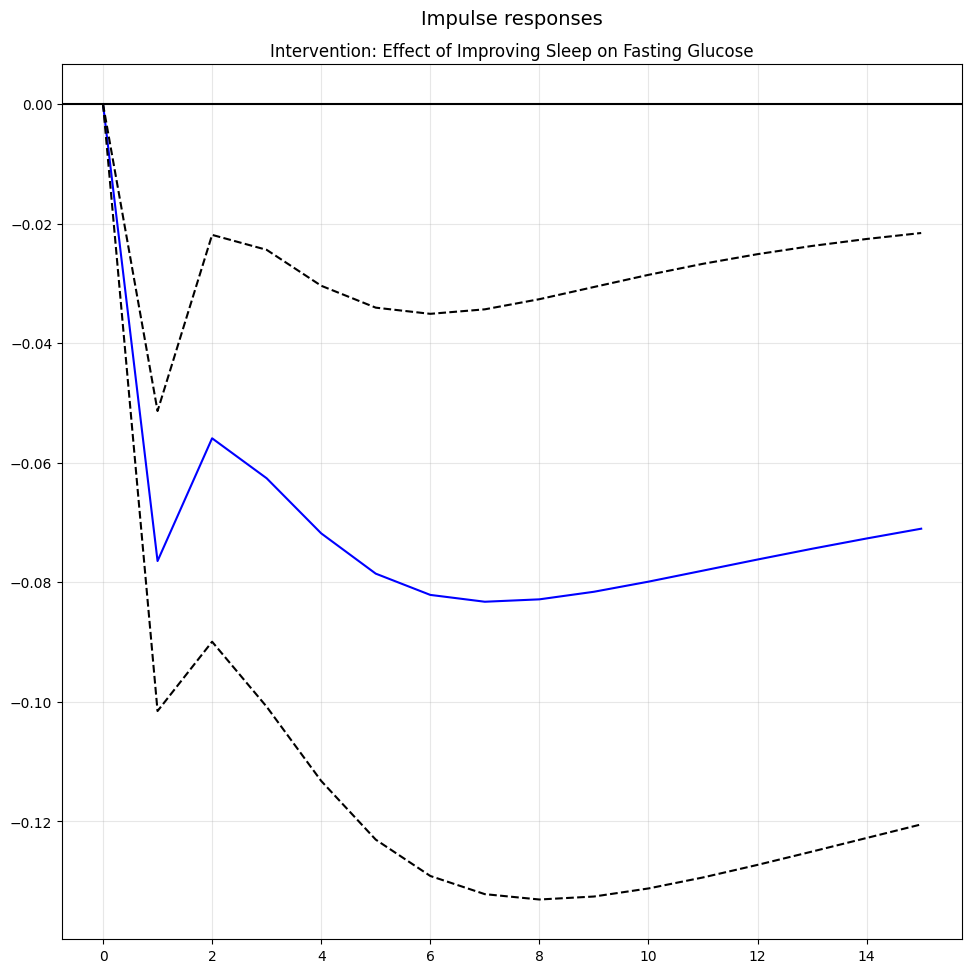

<Figure size 1000x500 with 0 Axes>

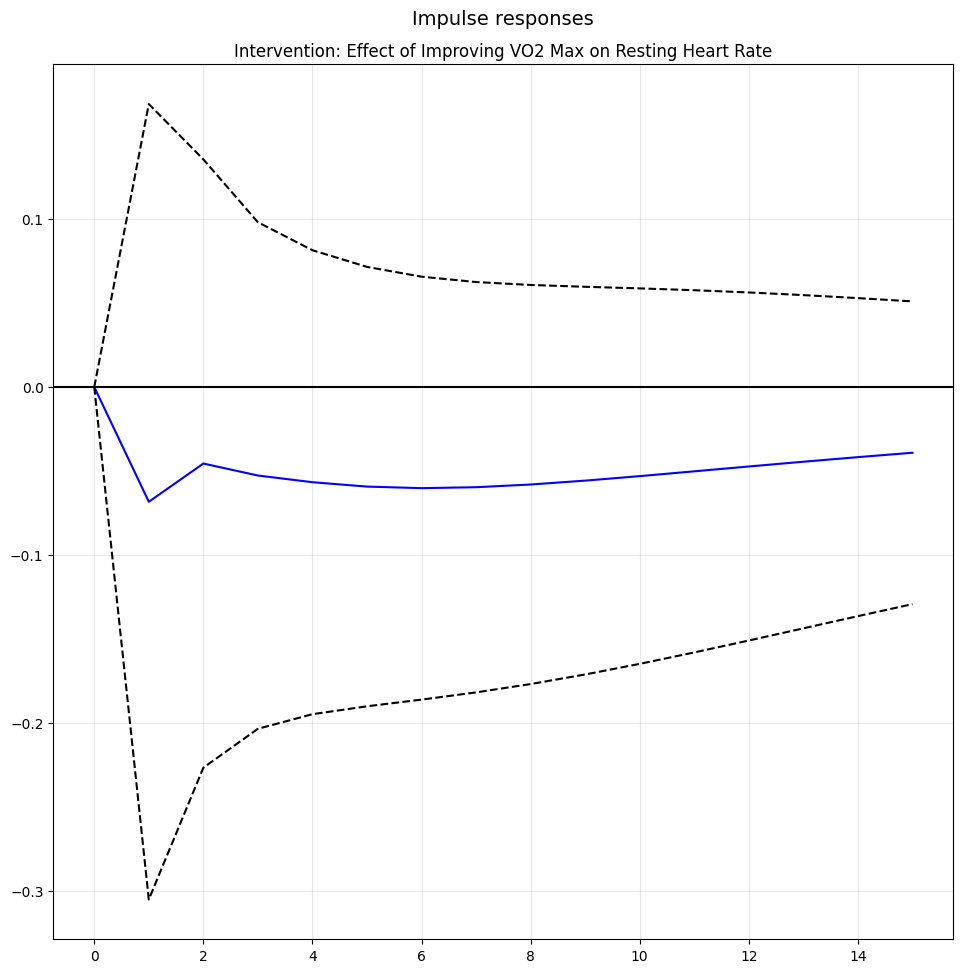

In [7]:
# STAGE 5: INTERVENTION SIMULATION
print("\nStage 5: Running Simulations...")

# Scenario 1: "If I force myself to Sleep better, what happens to my Glucose?"
irf = results.irf(15) # 15 days projection

plt.figure(figsize=(10, 5))
irf.plot(impulse='Sleep', response='Glucose')
plt.title("Intervention: Effect of Improving Sleep on Fasting Glucose")
plt.grid(True, alpha=0.3)
plt.show()

# Scenario 2: "If I improve my VO2 Max (get fitter), does my RHR go down?"
plt.figure(figsize=(10, 5))
irf.plot(impulse='VO2_Max', response='RHR')
plt.title("Intervention: Effect of Improving VO2 Max on Resting Heart Rate")
plt.grid(True, alpha=0.3)
plt.show()


Running Stage 6: Validation...


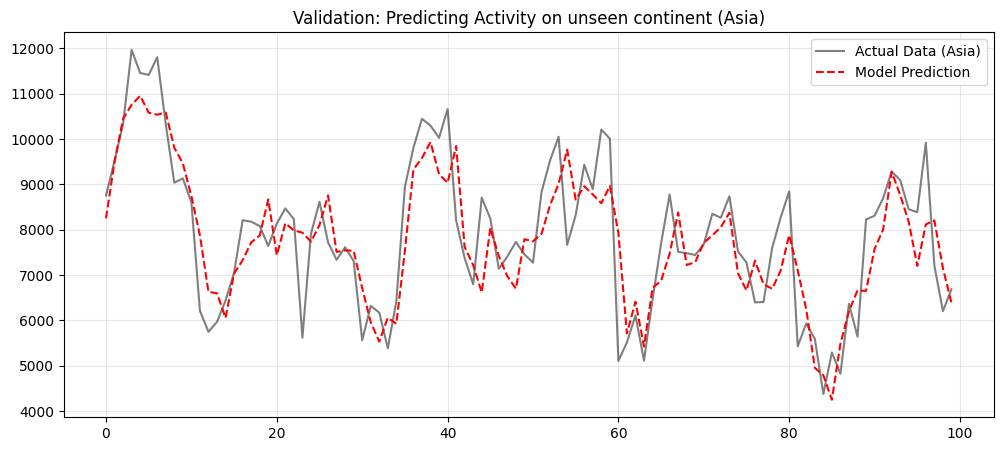

Validation Complete. RMSE on Unseen Data: 1001.70


<Figure size 800x600 with 0 Axes>

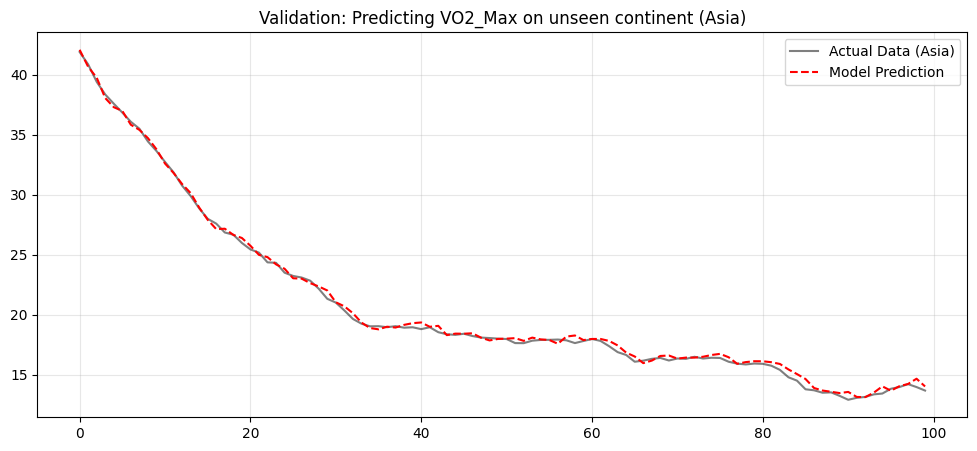

Validation Complete. RMSE on Unseen Data: 0.33


<Figure size 800x600 with 0 Axes>

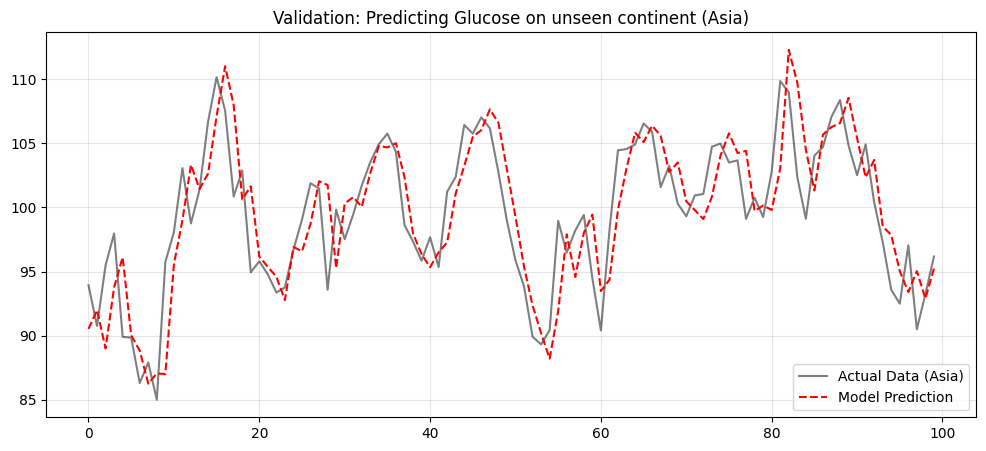

Validation Complete. RMSE on Unseen Data: 3.39


<Figure size 800x600 with 0 Axes>

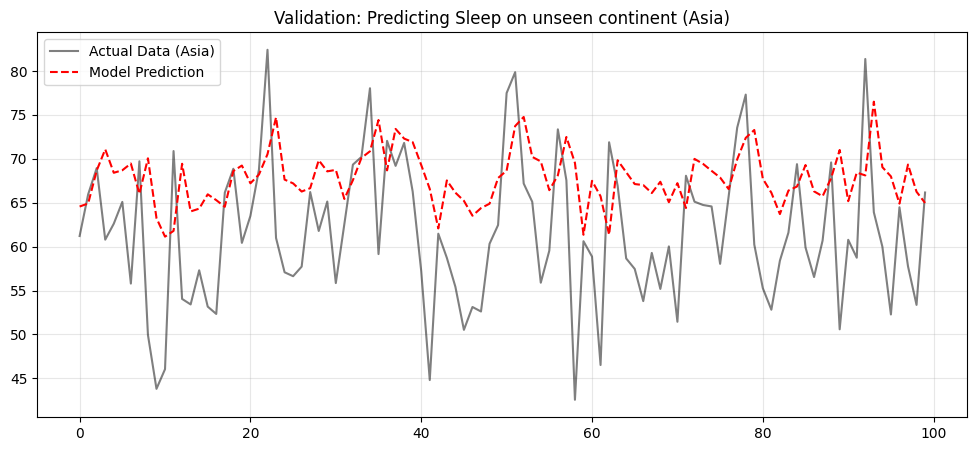

Validation Complete. RMSE on Unseen Data: 9.64


<Figure size 800x600 with 0 Axes>

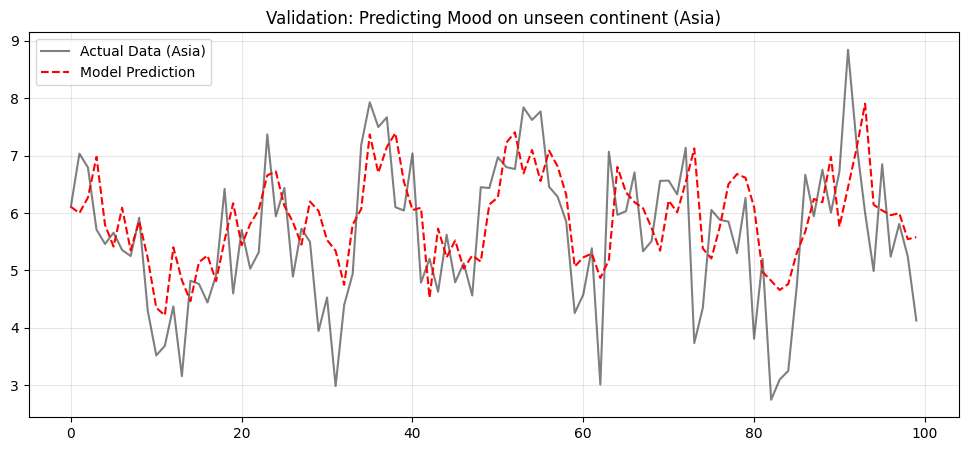

Validation Complete. RMSE on Unseen Data: 1.02


<Figure size 800x600 with 0 Axes>

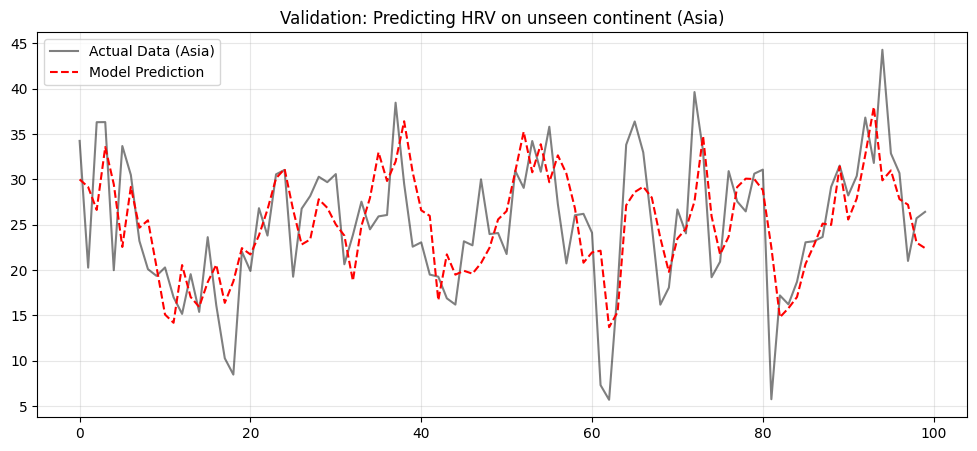

Validation Complete. RMSE on Unseen Data: 5.14


<Figure size 800x600 with 0 Axes>

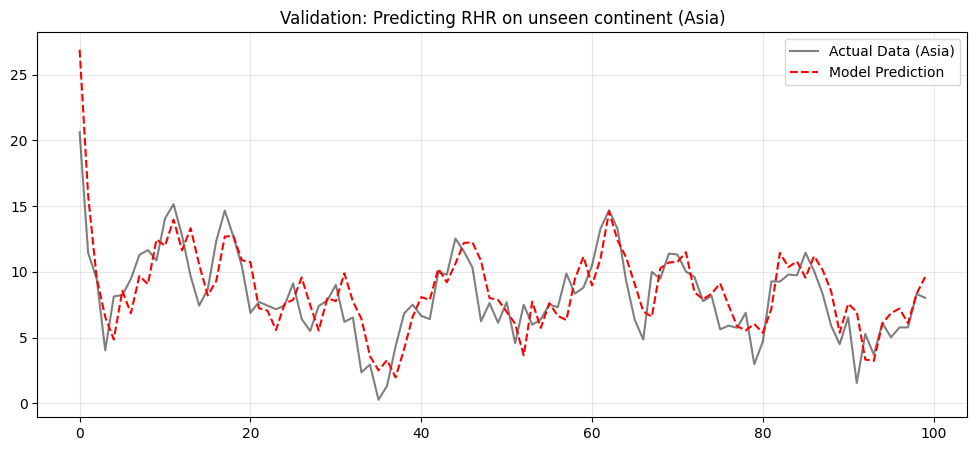

Validation Complete. RMSE on Unseen Data: 2.07


In [8]:

# STAGE 6: VALIDATION ON UNSEEN DATA
print("\nRunning Stage 6: Validation...")

# 1. Prepare Test Data
# We extract the raw numpy array to avoid the Index Warning you saw earlier.
test_values = df_test.values
lag_order = results.k_ar

predictions = []
actuals = []

# 2. Walk-Forward Validation
# For every day in the test set, use the previous 2 days (Lag 2) to predict today.
for i in range(lag_order, len(test_values)):
    # Input: The previous 'lag_order' days from the test set
    forecast_input = test_values[i-lag_order:i] 
    
    # Predict: The next single step
    pred = results.forecast(y=forecast_input, steps=1)
    
    predictions.append(pred[0])
    actuals.append(test_values[i])

# 3. Organize Results into DataFrames
pred_df = pd.DataFrame(predictions, columns=df_test.columns)
act_df = pd.DataFrame(actuals, columns=df_test.columns)

# 4. Visualize Accuracy (Focus on 'Activity')
def plot_validation(act_df, pred_df, variable):
    plt.figure(figsize=(12, 5))
    limit = 100 # Zoom in on the first 100 days for clarity
    plt.plot(act_df[variable][:limit].values, label='Actual Data (Asia)', color='black', alpha=0.5)
    plt.plot(pred_df[variable][:limit].values, label='Model Prediction', color='red', linestyle='--')
    plt.title(f"Validation: Predicting {variable} on unseen continent (Asia)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # 5. Score the Model
    rmse = np.sqrt(mean_squared_error(act_df[variable], pred_df[variable]))
    print(f"Validation Complete. RMSE on Unseen Data: {rmse:.2f}")

plot_validation(act_df, pred_df, 'Activity')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'VO2_Max')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'Glucose')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'Sleep')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'Mood')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'HRV')
plt.figure(figsize=(8, 6))
plot_validation(act_df, pred_df, 'RHR')
